In [3]:
import cv2
import sys
import matplotlib.pyplot as plt
import numpy as np

In [4]:
cd drive/MyDrive/

/content/drive/MyDrive


In [5]:
ls | grep chotoi

chotoixin1vedituoitho.jpg


Original Dimensions :  (720, 720)
Resized Dimensions :  (432, 432)


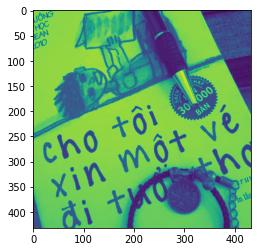

In [6]:
# part1: 
img = cv2.imread('chotoixin1vedituoitho.jpg', cv2.IMREAD_GRAYSCALE)
print('Original Dimensions : ',img.shape)

scale_percent = 60 
width = int(img.shape[1] * scale_percent / 100)
height = int(img.shape[0] * scale_percent / 100)
dim = (width, height)

# resize image
resized = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
print('Resized Dimensions : ',resized.shape)

plt.imshow(resized)
plt.show()

In [7]:
total_pixels = img.shape[0] * img.shape[1]
total_pixels

518400

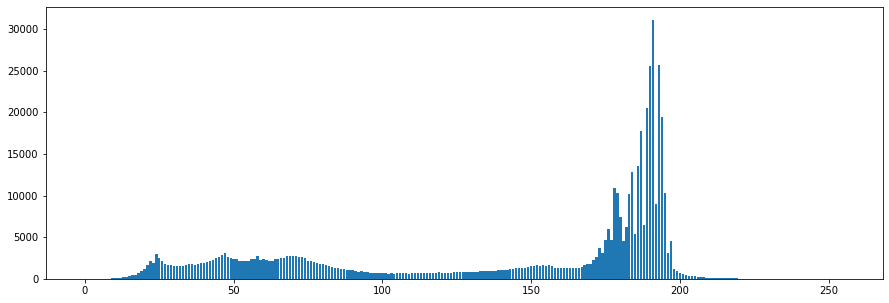

[8, 2, 9, 7, 7, 6, 16, 25, 27, 46, 62, 90, 129, 174, 229, 284, 406, 481, 643, 941, 1133, 1616, 2172, 1888, 2944, 2536, 2137, 1837, 1699, 1600, 1572, 1504, 1571, 1585, 1695, 1730, 1797, 1712, 1755, 1855, 1941, 2030, 2177, 2311, 2531, 2586, 2858, 3097, 2673, 2441, 2391, 2365, 2182, 2133, 2120, 2082, 2336, 2427, 2695, 2285, 2348, 2280, 2196, 2193, 2320, 2340, 2440, 2512, 2735, 2777, 2733, 2700, 2623, 2559, 2492, 2197, 2097, 2002, 1922, 1787, 1753, 1625, 1481, 1457, 1319, 1275, 1220, 1180, 1058, 1020, 1015, 929, 867, 879, 784, 775, 725, 730, 667, 682, 692, 673, 624, 678, 632, 647, 657, 698, 640, 629, 663, 686, 663, 669, 669, 693, 657, 691, 698, 759, 741, 720, 729, 689, 795, 814, 781, 804, 829, 772, 781, 833, 810, 954, 898, 886, 887, 936, 984, 1024, 1018, 1080, 1103, 1231, 1228, 1299, 1274, 1332, 1298, 1475, 1573, 1577, 1674, 1591, 1693, 1547, 1693, 1483, 1316, 1305, 1274, 1266, 1301, 1334, 1317, 1349, 1349, 1447, 1612, 1744, 1737, 2299, 2653, 3683, 3138, 4628, 5964, 4603, 10892, 10348, 740

In [8]:
# part2
L = 256

his = [0 for i in range(256)]
for val in img.flatten():
    his[val] += 1

plt.figure(figsize=(15, 5))
plt.bar(np.array(range(L)), np.array(his))
plt.show()

print(his)

In [9]:
# Histogram Specification
P = [i / total_pixels for i in his]
S_k = []

lens = len(P)
for i in range(0, lens): 
  sub = 0
  for j in range(0,i+1): 
    sub += P[j]
  S_k.append(sub)

S_k
S_k = [i * 255 for i in S_k]

In [10]:
output_img = [S_k[pixel] for pixel in img.flatten()]
output_img = np.reshape(np.array(output_img), (img.shape[0], img.shape[1]))
# output_img = np.round(output_img)
print(output_img)

[[188.34976852 188.34976852 188.34976852 ...  35.17711227  26.31950231
   19.64149306]
 [188.34976852 188.34976852 188.34976852 ...  43.08585069  34.10379051
   29.24875579]
 [200.93252315 200.93252315 200.93252315 ...  43.08585069  31.76432292
   30.56359954]
 ...
 [ 45.36235532  45.36235532  46.44256366 ... 136.7958912  136.7958912
  136.7958912 ]
 [ 44.24082755  44.24082755  44.24082755 ... 131.70572917 131.70572917
  131.70572917]
 [ 43.08585069  43.08585069  44.24082755 ... 131.70572917 131.70572917
  131.70572917]]


In [11]:
np.round(output_img)

array([[188., 188., 188., ...,  35.,  26.,  20.],
       [188., 188., 188., ...,  43.,  34.,  29.],
       [201., 201., 201., ...,  43.,  32.,  31.],
       ...,
       [ 45.,  45.,  46., ..., 137., 137., 137.],
       [ 44.,  44.,  44., ..., 132., 132., 132.],
       [ 43.,  43.,  44., ..., 132., 132., 132.]])

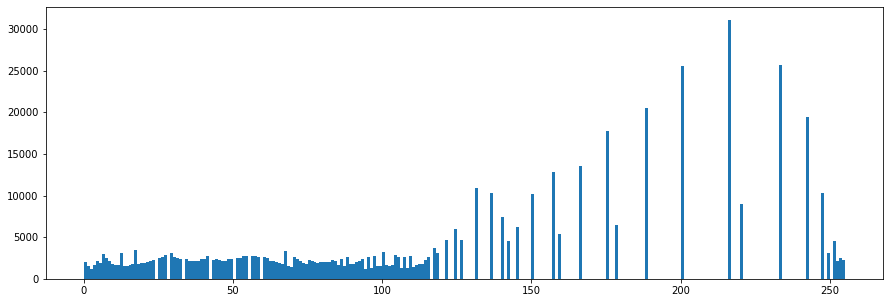

In [12]:
plt.figure(figsize=(15, 5))
plt.hist(output_img.flatten(), range(L))
plt.show()

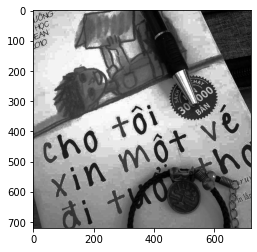

In [13]:
plt.imshow(output_img, cmap='gray', vmin = 0, vmax = 255)
plt.show()

In [14]:
cv2.imwrite('imagenew.jpg', output_img)

True

In [ ]:
# part 4

def gray_img(path):
    img_src = cv2.imread(cv2.samples.findFile(path))
    img_src = cv2.equalizeHist(cv2.cvtColor(img_src, cv2.COLOR_BGR2GRAY))

    return img_src

def average_filter(img, size = 5):
    return cv2.blur(img,(size,size))

def gaussian_filter(img, size = 5):
    return cv2.GaussianBlur(img,(size,size),0)

def median_filter(img, size = 3): 
  return cv2.medianBlur(img, size)

def hight_pass_filter(img):
    kernel_hight_pass = np.array([[-1, -1, -1.0], 
                                [-1, 8, -1],
                                [-1, -1, -1.0]])

    img_res = cv2.filter2D(img,-1,kernel_hight_pass)

    return img_res

def horizontal_edge_detect(img):
    kernel_horizontal_edge = np.array([[1, 2, 1],
                                [0, 0, 0],
                                [-1, -2, -1]])

    img_horizontal_edge = cv2.filter2D(img,-1,kernel_horizontal_edge)

    return img_horizontal_edge

def vertical_edge_detect(img):
    kernel_vertical_edge = np.array([[1, 0, -1.0], 
                                [2.0, 0, -2.0],
                                [1.0, 0, -1.0]])

    img_vertical_edge = cv2.filter2D(img,-1,kernel_vertical_edge)

    return img_vertical_edge

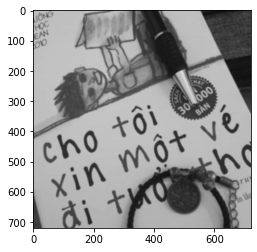

In [ ]:
plt.imshow(average_filter(img), cmap='gray', vmin = 0, vmax = 255)
plt.show()

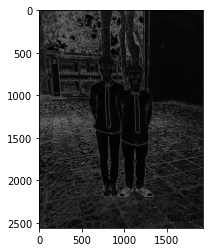

In [ ]:
plt.imshow(hight_pass_filter(img), cmap='gray', vmin = 0, vmax = 255)
plt.show()

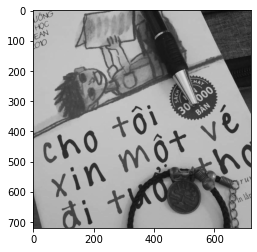

In [ ]:
plt.imshow(median_filter(img), cmap='gray', vmin = 0, vmax = 255)
plt.show()

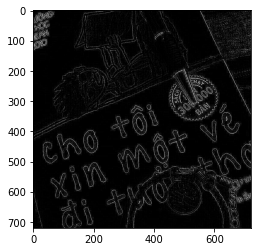

<Figure size 21600x21600 with 0 Axes>

In [ ]:
plt.imshow(hight_pass_filter(img), cmap='gray', vmin = 0, vmax = 255)
plt.figure(figsize=(300, 300))
plt.show()

True